In [50]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import time
from pathlib import Path

In [61]:
dataset_name = "kaysons_generated_networks_routing"
path_01_connectomes = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/{dataset_name}/01_connectomes/routing_20_percent.npy")
np.load(path_01_connectomes)[5, :, :].mean() # .sum()

0.198

In [2]:
df = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/kaysons_generated_networks_diffusion/05_mst_animal_0_compared_with_diffusions/summary_indiv_delta_con_for_exp_05_mst_animal_0_compared_with_diffusions.csv")

In [3]:
df

,network_index,filename,eta,gamma,id,DeltaCon_subject_0,DeltaCon_subject_1,DeltaCon_subject_2,DeltaCon_subject_3,DeltaCon_subject_4,...,DeltaCon_subject_90,DeltaCon_subject_91,DeltaCon_subject_92,DeltaCon_subject_93,DeltaCon_subject_94,DeltaCon_subject_95,DeltaCon_subject_96,DeltaCon_subject_97,DeltaCon_subject_98,DeltaCon_subject_99
0,0,net_eta1.653061270713806_gamma0.66326528787612...,1.653061,0.663265,0,12.668827,12.668827,12.668827,12.668827,12.668827,...,12.668827,12.668827,12.668827,12.668827,12.668827,12.668827,12.668827,12.668827,12.668827,12.668827
1,1,net_eta-1.040816307067872_gamma0.0346938744187...,-1.040816,0.034694,0,8.187947,8.187947,8.187947,8.187947,8.187947,...,8.187947,8.187947,8.187947,8.187947,8.187947,8.187947,8.187947,8.187947,8.187947,8.187947
2,2,net_eta-7.775510311126709_gamma-0.100000001490...,-7.775510,-0.100000,0,9.755045,9.755045,9.755045,9.755045,9.755045,...,9.755045,9.755045,9.755045,9.755045,9.755045,9.755045,9.755045,9.755045,9.755045,9.755045
3,3,net_eta-1.265306115150452_gamma0.5285714268684...,-1.265306,0.528571,0,9.300138,9.300138,9.300138,9.300138,9.300138,...,9.300138,9.300138,9.300138,9.300138,9.300138,9.300138,9.300138,9.300138,9.300138,9.300138
4,4,net_eta-4.18367338180542_gamma0.21428570151329...,-4.183673,0.214286,0,7.530113,7.530113,7.530113,7.530113,7.530113,...,7.530113,7.530113,7.530113,7.530113,7.530113,7.530113,7.530113,7.530113,7.530113,7.530113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24995,net_eta-3.061224460601807_gamma-0.010204084217...,-3.061224,-0.010204,9,7.437542,7.437542,7.437542,7.437542,7.437542,...,7.437542,7.437542,7.437542,7.437542,7.437542,7.437542,7.437542,7.437542,7.437542,7.437542
24996,24996,net_eta0.530612289905548_gamma0.48367348313331...,0.530612,0.483673,9,9.856299,9.856299,9.856299,9.856299,9.856299,...,9.856299,9.856299,9.856299,9.856299,9.856299,9.856299,9.856299,9.856299,9.856299,9.856299
24997,24997,net_eta1.653061270713806_gamma0.50612246990203...,1.653061,0.506122,9,12.781235,12.781235,12.781235,12.781235,12.781235,...,12.781235,12.781235,12.781235,12.781235,12.781235,12.781235,12.781235,12.781235,12.781235,12.781235
24998,24998,net_eta-2.612245082855225_gamma0.6408163309097...,-2.612245,0.640816,9,9.666313,9.666313,9.666313,9.666313,9.666313,...,9.666313,9.666313,9.666313,9.666313,9.666313,9.666313,9.666313,9.666313,9.666313,9.666313


In [11]:
df.drop(columns=["filename"], inplace=True)

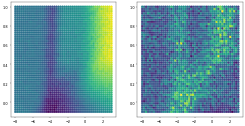

In [31]:
df_mean = df.groupby(["eta", "gamma"]).mean() # ["DeltaCon_subject_20"].mean().reset_index()
df_std = df.groupby(["eta", "gamma"]).std() # ["DeltaCon_subject_20"].mean().reset_index()

# reset index 
df_mean.reset_index(inplace=True)
df_std.reset_index(inplace=True)

plt.figure(figsize=(12,6), dpi=25)
plt.subplot(1,2,1)
plt.scatter(df_mean["eta"], df_mean["gamma"], c=df_mean["DeltaCon_subject_20"])
plt.subplot(1,2,2)
plt.scatter(df_std["eta"], df_std["gamma"], c=df_std["DeltaCon_subject_20"])

# This one is just a check: Are the individual landscapes similar enough to justify averaging? 

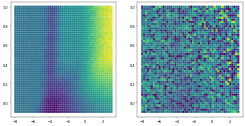

In [43]:
# Add a column for the mean and std of all the Deltacon... values for each eta gamma pair 
df_mean["DeltaCon_mean"] = np.array([df_mean[f"DeltaCon_subject_{id}"] for id in range(100)]).mean(axis=0)
df_mean["DeltaCon_std"] = np.array([df_mean[f"DeltaCon_subject_{id}"] for id in range(100)]).std(axis=0)

plt.figure(figsize=(12,6), dpi=25)
plt.subplot(1,2,1)
plt.scatter(df_mean["eta"], df_mean["gamma"], c=df_mean["DeltaCon_mean"])
plt.subplot(1,2,2)
plt.scatter(df_mean["eta"], df_mean["gamma"], c=df_mean["DeltaCon_std"])

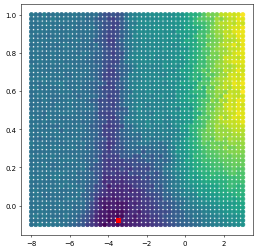

In [48]:
plt.figure(figsize=(6,6), dpi=50)

plt.scatter(df_mean["eta"], df_mean["gamma"], c=df_mean["DeltaCon_mean"])

for i in range(100): 
    # get row with minimum DeltaCon for subject i
    min_row = df_mean[df_mean[f"DeltaCon_subject_{i}"] == df_mean[f"DeltaCon_subject_{i}"].min()]
    plt.scatter(min_row["eta"], min_row["gamma"], c="red", label=f"min DeltaCon subject {i}")
    # print(min_row[["eta", "gamma", f"DeltaCon_subject_{i}"]])

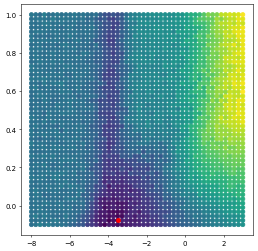

In [ ]:
# scatter all the minima of the DeltaCon columns of df_mean
plt.figure(figsize=(6,6), dpi=50)

plt.scatter(df_mean["eta"], df_mean["gamma"], c=df_mean["DeltaCon_subject_20"])
for i in range(100): 
plt.scatter(df_mean["eta"][df_mean["DeltaCon_subject_20"] == df_mean["DeltaCon_subject_20"].min()], df_mean["gamma"][df_mean["DeltaCon_subject_20"] == df_mean["DeltaCon_subject_20"].min()], c="red", label="min DeltaCon")

In [4]:
# Find the row with the minimum value for each "DeltaCon" column
delta_con_columns = [col for col in df.columns if "DeltaCon" in col]
min_rows = df[delta_con_columns].idxmin()

# plot the values of the "DeltaCon" columns for the row with the minimum value
for col in delta_con_columns:
    plt.figure()
    sns.barplot(x=df.columns, y=df.loc[min_rows[col], delta_con_columns])
    plt.title(f"DeltaCon values for row with minimum {col}")
    plt.xlabel("DeltaCon Columns")
    plt.ylabel("DeltaCon Value")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

ValueError: array length 105 does not match index length 100

<Figure size 640x480 with 0 Axes>